In [1]:
from netgen.meshing import Mesh
from ngsolve import *
from netgen.occ import *
from ngsolve.webgui import Draw

import matplotlib.pylab as plt
import scipy.sparse as sp

In [2]:
def Capacitor3DGeometry():
    air_box = Box((-10, -10, -10), (10, 10, 10))
    air_box.faces.name = "Outer"  

    dielectric = Box((-2, -0.75, -1.5), (2, 0.75, 1.5))
    dielectric.name = "dielectric"

    electrode_positive = Box((-2.5, 0.75, -2), (2.5, 1.25, 2))
    electrode_positive.faces.name = "electrode_positive"

    electrode_negative = Box((-2.5, -1.25, -2), (2.5, -0.75, 2))
    electrode_negative.faces.name = "electrode_negative"

    air = air_box - dielectric
    air.name = "air"

    shape = Glue([air, dielectric])
    shape = shape - electrode_positive - electrode_negative

    return shape


def Capacitor3DMesh(shape, h_max):
    
    mesh = Mesh(OCCGeometry(shape, dim=3).GenerateMesh(maxh=h_max))

    return mesh



def Capacitor3DSolver(mesh, FE_order, epsr):

    fes = H1(mesh, order=FE_order, dirichlet="el.*")

    u = fes.TrialFunction()
    v = fes.TestFunction()

    solution_gf = GridFunction(fes)
    solution_gf.Interpolate(mesh.BoundaryCF({"electrode_positive":1, "electrode_negative":-1 }), mesh.Boundaries(".*"))

    a = BilinearForm(epsr*grad(u)*grad(v)*dx).Assemble()
    
    inv = a.mat.Inverse(freedofs=fes.FreeDofs())
    solution_gf.vec.data -= inv@a.mat * solution_gf.vec

    return solution_gf, a


In [3]:
geo = Capacitor3DGeometry()

clipping = {
    "function": True,
    "pnt": (0, 0, 0),
    "vec": (0, 0, -1)
}

Draw(geo, clipping=clipping);

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'ngsolve_version': 'Netgen x.x', 'mesh_dim': …

In [4]:
h_max = 0.6
mesh = Capacitor3DMesh(geo, h_max)

Draw(mesh, clipping=clipping, settings={"Objects": {"Surface": True}});

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Objects': {'Surface': True}…

In [5]:
epsr_air = 1.0
epsr_dielectric = 4.0

epsr = mesh.MaterialCF({"air": epsr_air, "dielectric": epsr_dielectric})

Draw(epsr, mesh, draw_surf=False, draw_vol=True, clipping=clipping)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

In [6]:
FE_order = 2

phi_gf, a = Capacitor3DSolver(mesh, FE_order, epsr)

In [7]:
Draw (phi_gf, deformation=True, scale=5, clipping=clipping);

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [8]:
fes_flux = HCurl(mesh, order=FE_order-1)

E_gf = GridFunction(fes_flux)
E_gf.Set(-grad(phi_gf))

In [9]:
Draw (E_gf, mesh, vectors= {"grid_size": 100}, clipping=clipping);

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [10]:
N = 100
p = [(-10 + 0.2*i, -10 + 0.2*j, -10 + 0.2*k) for i in range(N) for j in range(N) for k in range(N)] 

fieldlines = E_gf._BuildFieldLines(mesh, p, num_fieldlines=400, length=3)

Draw(E_gf, mesh,  "X", draw_vol=True, draw_surf=True, objects=[fieldlines], \
     autoscale=True, min = 0, max = 1, settings={"Objects": {"Surface": False}});

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Objects': {'Surface': False…

In [11]:
energy = 0.5 * Integrate(epsr*InnerProduct(E_gf, E_gf), mesh, definedon=mesh.Materials("dielectric"))
print(energy)

54.435679183593045


In [12]:
energy = 0.5 * Integrate(epsr*InnerProduct(E_gf, E_gf), mesh)
print(energy)

94.39477478630937


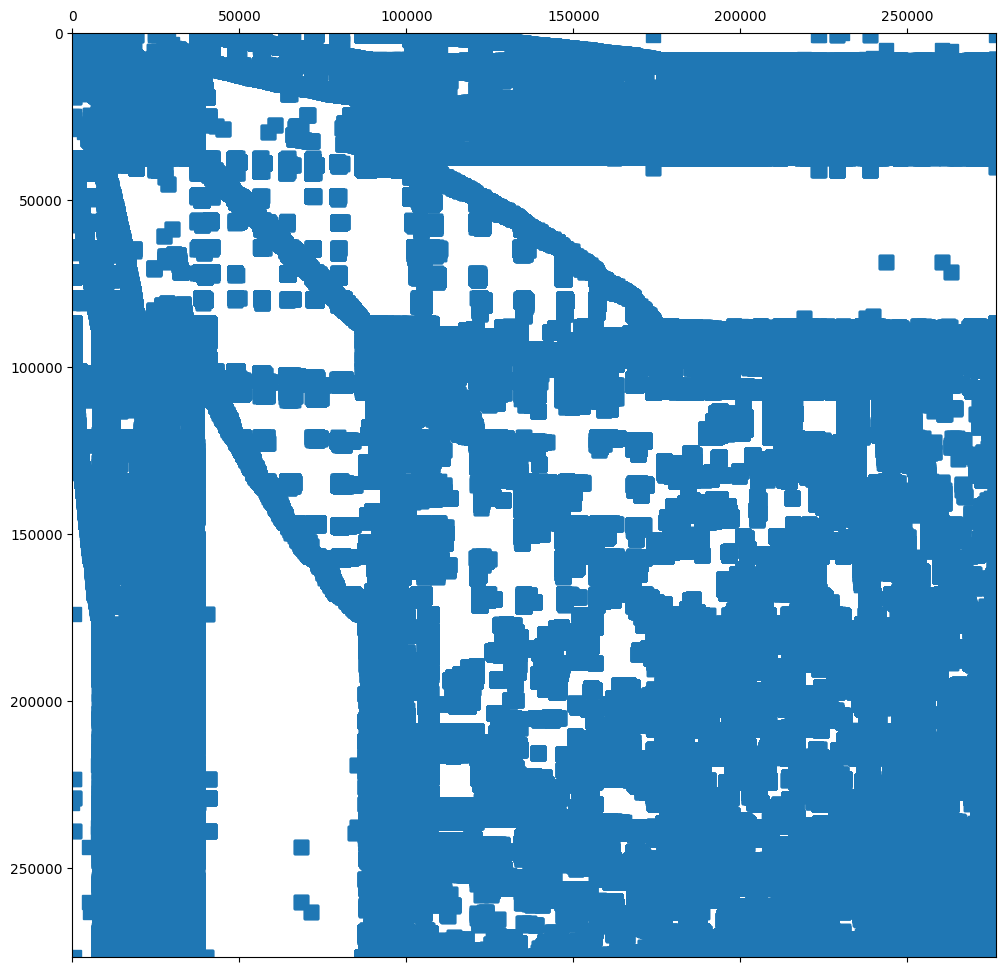

In [13]:
plt.rcParams['figure.figsize'] = (12, 12)
A = sp.csr_matrix(a.mat.CSR())

plt.spy(A)
plt.show()

In [14]:
n = a.mat.height
density = a.mat.nze / (n*n)
print("Ukupan broj elemenata:", n*n)
print("Broj nenul elemenata:", a.mat.nze)
print("Popunjenost:", density)

Ukupan broj elemenata: 76530242881
Broj nenul elemenata: 7631651
Popunjenost: 9.972072102092718e-05
